---
title: "Curvas de Bézier y Álgebra Lineal"
subtitle: "Resolución Integral - Trabajo Práctico 01"
author: "Métodos Computacionales"
date: "Mayo 2026"
format: 
  revealjs:
    theme: simple
    transition: fade
    slide-number: true
    echo: false
---

## Introducción
- Las **Curvas de Bézier** son herramientas fundamentales en diseño geométrico computacional [1].
- Matemáticamente, se definen como **combinaciones lineales** de funciones base en el espacio de polinomios $\mathbb{P}_n$ [1, 2].
- Este trabajo analiza la relación entre puntos de control, bases polinómicas y representaciones matriciales [3].

## Ejercicio 1. Interpolación Lineal 
- Dados $P_0 = (1, 2)$ y $P_1 = (5, 4)$, se define $L(t) = (1 - t)P_0 + tP_1$ [4].
- Es una **combinación convexa**: los pesos $(1-t)$ y $t$ son no negativos y suman 1 en $t \in [0, 1]$ [5].
- Esto garantiza que el punto $L(t)$ siempre esté sobre el segmento que une los extremos [6].

[1 2]
[5 4]
[3. 3.]
[1.         1.04040404 1.08080808 1.12121212 1.16161616 1.2020202
 1.24242424 1.28282828 1.32323232 1.36363636 1.4040404  1.44444444
 1.48484848 1.52525253 1.56565657 1.60606061 1.64646465 1.68686869
 1.72727273 1.76767677 1.80808081 1.84848485 1.88888889 1.92929293
 1.96969697 2.01010101 2.05050505 2.09090909 2.13131313 2.17171717
 2.21212121 2.25252525 2.29292929 2.33333333 2.37373737 2.41414141
 2.45454545 2.49494949 2.53535354 2.57575758 2.61616162 2.65656566
 2.6969697  2.73737374 2.77777778 2.81818182 2.85858586 2.8989899
 2.93939394 2.97979798 3.02020202 3.06060606 3.1010101  3.14141414
 3.18181818 3.22222222 3.26262626 3.3030303  3.34343434 3.38383838
 3.42424242 3.46464646 3.50505051 3.54545455 3.58585859 3.62626263
 3.66666667 3.70707071 3.74747475 3.78787879 3.82828283 3.86868687
 3.90909091 3.94949495 3.98989899 4.03030303 4.07070707 4.11111111
 4.15151515 4.19191919 4.23232323 4.27272727 4.31313131 4.35353535
 4.39393939 4.43434343 4.47474747 4.51515152

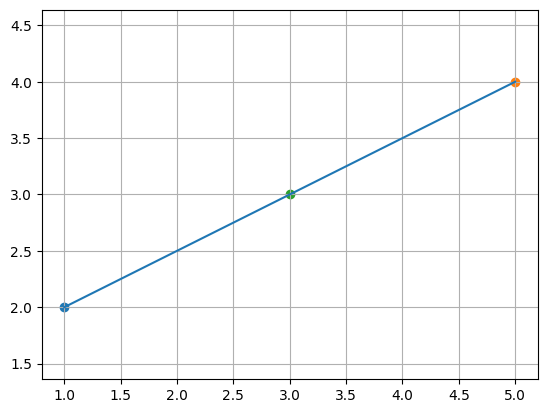

In [1]:
import numpy as np
import matplotlib.pyplot as plt

P0 = np.array([1, 2])
P1 = np.array([5, 4])
t = np.linspace(0, 1, 100)

def L(t):
    return (1 - t) * P0 + t * P1

#Ejercicio 1A
L0 = L(0)
print(L0)
L1 = L(1)
print(L1)
Lmed = L(0.5)
print(Lmed)
#Ejercicio 1B
puntos = L(t[:, np.newaxis])
x = puntos[:, 0]
print(x)
y = puntos[:, 1]
print(y)

#Ejercicio 1C
plt.plot(x, y)
plt.scatter(P0[0], P0[1])
plt.scatter(P1[0], P1[1])
plt.scatter(Lmed[0], Lmed[1])
plt.grid(True)
plt.axis("equal")
plt.show()

#Ejercicio 1D
#L(t) representa un segmento entre P0 y P1 porque la funcion L recorre los valores en linea 
#recta. En su minimo, cuando t=0 la funcion nos devuelve P0 y en su maximo t=1 nos devuelve 
#P1. En el medio, se va alejando de P0 tanto como se acerca a P1

## Ejercicio 2. Curva Cuadrática 

- Se construye con tres puntos de control: $P_0=(1,1)$, $P_1=(2,4)$, $P_2=(4,0)$.
- Primero se arman dos interpolaciones lineales: $Q_0(t)$ entre $P_0$ y $P_1$, y $Q_1(t)$ entre $P_1$ y $P_2$.
- Después se interpola entre $Q_0(t)$ y $Q_1(t)$ para obtener $B(t)$.

[1 1]
[4 0]
[2.25 2.25]


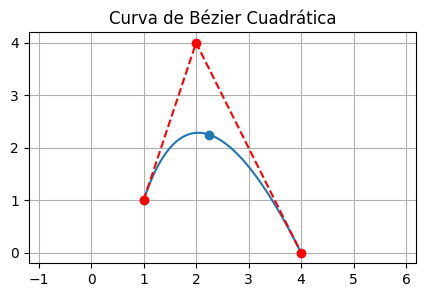

In [2]:
P0 = np.array([1, 1])
P1 = np.array([2, 4])
P2 = np.array([4, 0])
t = np.linspace(0, 1, 100)

def Q0(t):
    return (1 - t) * P0 + t * P1

def Q1(t):
    return (1 - t) * P1 + t * P2

def B(t):
    return (1 - t) * Q0(t) + t * Q1(t)

#Ejercicio 2A
#Q0(t) = (1 + t, 1 + 3t)
#Q1(t) = (2 + 2t, 4 - 4t)

#Ejercicio 2B
#B(t) = (1 + 2t + t^2, 1 + 6t - 7t^2)

#Ejercicio 2C
B0 = B(0)
print(B0)
B1 = B(1)
print(B1)
Bmed = B(0.5)
print(Bmed)

#Ejercicio 2D
#B(0) = P0 y B(1) = P2. La curva empieza en el primer punto y termina en el ultimo.

puntos = B(t[:, np.newaxis])
x = puntos[:, 0]
y = puntos[:, 1]

plt.figure(figsize=(5, 3))
plt.plot(x, y)
plt.plot([P0[0], P1[0], P2[0]], [P0[1], P1[1], P2[1]], 'ro--')
plt.scatter(Bmed[0], Bmed[1])
plt.title("Curva de Bézier Cuadrática")
plt.grid(True)
plt.axis("equal")
plt.show()

## Ejercicio 3. Importancia del Orden 

- La curva depende estrictamente de la secuencia de los puntos de control.
- Permutar los puntos intermedios $(P_0, P_2, P_1, P_3)$ genera una trayectoria diferente.
- Esto se debe a que los polinomios de Bernstein asignan pesos distintos según la posición en la lista.


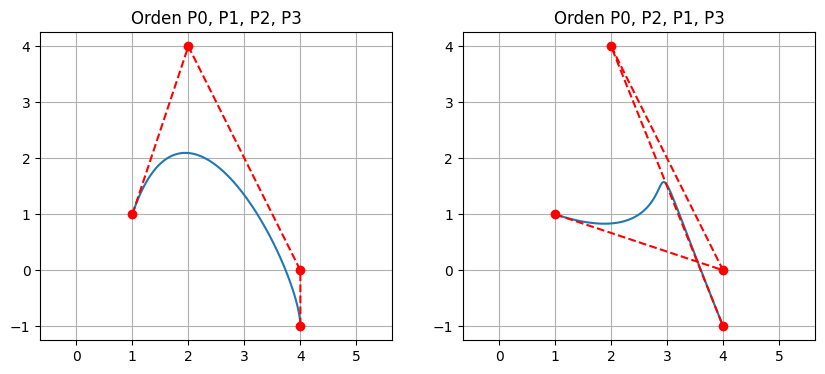

In [3]:
P0 = np.array([1, 1])
P1 = np.array([2, 4])
P2 = np.array([4, 0])
P3 = np.array([4, -1])
t = np.linspace(0, 1, 100)

def interpolar(t, A, B):
    return (1 - t) * A + t * B

#En esta ocasion no me dan la formula de la curva, pero veo como se construian antes recursivamente
#y noto que puedo agregar un paso y calcular la curva con un punto mas que antes.

def calcular_curva(t, P0, P1, P2, P3):
    Q0 = interpolar(t, P0, P1)
    Q1 = interpolar(t, P1, P2)
    Q2 = interpolar(t, P2, P3)

    R0 = interpolar(t, Q0, Q1)
    R1 = interpolar(t, Q1, Q2)

    return interpolar(t, R0, R1)

#Ejercicio 3A
curva1 = calcular_curva(t[:, np.newaxis], P0, P1, P2, P3)

#Ejercicio 3C
curva2 = calcular_curva(t[:, np.newaxis], P0, P2, P1, P3)

#Ejercicio 3B y 3D
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(curva1[:, 0], curva1[:, 1])
plt.plot([P0[0], P1[0], P2[0], P3[0]], [P0[1], P1[1], P2[1], P3[1]], "ro--")
plt.title("Orden P0, P1, P2, P3")
plt.grid(True)
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.plot(curva2[:, 0], curva2[:, 1])
plt.plot([P0[0], P2[0], P1[0], P3[0]], [P0[1], P2[1], P1[1], P3[1]], "ro--")
plt.title("Orden P0, P2, P1, P3")
plt.grid(True)
plt.axis("equal")

plt.show()

#La curva claramente no es la misma. Depende del orden de los puntos porque al cambiar P1 y P2
#cambia el camino de interpolaciones. Aunque los puntos sean los mismos, cada uno ocupa otro rol
#en la construccion de la curva.


## Ejercicio 4. Puntos de Control y Linealidad 

- $P_0$ y $P_3$ son interpolados ($B(0)=P_0$ y $B(1)=P_3$).
- $P_1$ y $P_2$ determinan las tangentes en los extremos.
- La dependencia es lineal: si se desplaza un punto de control, la curva se desplaza proporcionalmente.

In [4]:
#Ejercicio 4A
#Los puntos de control son P0, P1, P2 y P3.

#Ejercicio 4B
#B(0) = P0
#B(1) = P3

#Lo verifico con una funcion general de Bezier cubica.
def B_cubica(t, P0, P1, P2, P3):
    return (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3

P0 = np.array([1, 1])
P1 = np.array([2, 4])
P2 = np.array([4, 0])
P3 = np.array([4, -1])

print(B_cubica(0, P0, P1, P2, P3))
print(B_cubica(1, P0, P1, P2, P3))

#Ejercicio 4C
#P1 y P2 no tienen por que estar sobre la curva. Sirven para controlar la forma.
#P1 influye en como sale la curva desde P0 y P2 influye en como llega hacia P3.

#Ejercicio 4D
#La dependencia respecto de P0, P1, P2 y P3 es lineal porque la curva es una suma de
#esos puntos multiplicados por coeficientes que dependen de t. Los puntos no se multiplican
#entre si ni aparecen elevados a potencias.


[1 1]
[ 4 -1]


### Espacios Vectoriales de Polinomios

- Trabajamos en $\mathbb{P}_3$, el espacio de polinomios de grado $\leq 3$.
- La base monomial estándar es $\{1, t, t^2, t^3\}$.
- Para Bézier, utilizamos la **Base de Bernstein**.


## 7. Polinomios de Bernstein (Ejercicio 5)

Expansión en la base monomial:

- $b_0(t) = 1 - 3t + 3t^2 - t^3$
- $b_1(t) = 3t - 6t^2 + 3t^3$
- $b_2(t) = 3t^2 - 3t^3$
- $b_3(t) = t^3$

In [5]:
#Ejercicio 5A
#Los escribo en la forma a + bt + ct^2 + dt^3.
#b0(t) = (1 - t)^3 = 1 - 3t + 3t^2 - t^3
#b1(t) = 3(1 - t)^2t = 3t - 6t^2 + 3t^3
#b2(t) = 3(1 - t)t^2 = 3t^2 - 3t^3
#b3(t) = t^3

#Ejercicio 5B
#Cada vector guarda los coeficientes en el orden [1, t, t^2, t^3].
b0 = np.array([1, -3, 3, -1])
b1 = np.array([0, 3, -6, 3])
b2 = np.array([0, 0, 3, -3])
b3 = np.array([0, 0, 0, 1])

print(b0)
print(b1)
print(b2)
print(b3)

#Ejercicio 5C
#Construyo la matriz A usando esos vectores como columnas.
A = np.column_stack((b0, b1, b2, b3))
print(A)

#Ejercicio 5D
#La matriz A contiene las coordenadas de los polinomios de Bernstein en la base monomial.
#Cada columna representa uno de los polinomios

#Ejercicio 5E
#La matriz A es triangular inferior.
#Entonces su determinante es el producto de los elementos de la diagonal:
#det(A) = 1 * 3 * 3 * 1 = 9.
#Como el determinante es distinto de 0, A es invertible.

#Ejercicio 5F
#Como A es invertible, sus columnas son linealmente independientes.
#Pero las columnas de A representan los cuatro polinomios dados en la base monomial.
#Entonces los polinomios tambien son linealmente independientes.
#Ademas, como son cuatro polinomios linealmente independientes en P3,
#forman una base de P3.



[ 1 -3  3 -1]
[ 0  3 -6  3]
[ 0  0  3 -3]
[0 0 0 1]
[[ 1  0  0  0]
 [-3  3  0  0]
 [ 3 -6  3  0]
 [-1  3 -3  1]]


## Ejercicio 6. La Matriz de Bézier 

Representamos la curva como $B(t) = [P] \cdot M \cdot [T]$.

La matriz $M$ contiene los coeficientes de los polinomios de Bernstein:

$$M = \begin{pmatrix} 1 & 0 & 0 & 0 \\ -3 & 3 & 0 & 0 \\ 3 & -6 & 3 & 0 \\ -1 & 3 & -3 & 1 \end{pmatrix}$$


In [6]:
#Ejercicio 6A
#La curva cubica se puede escribir en forma matricial como:
#[P0 P1 P2 P3] M [1, t, t^2, t^3]^T

#Ejercicio 6B
#La matriz M tiene como columnas los coeficientes de los polinomios de Bernstein
#escritos en la base monomial [1, t, t^2, t^3].
M = np.array([[1, 0, 0, 0],
              [-3, 3, 0, 0],
              [3, -6, 3, 0],
              [-1, 3, -3, 1]])

print(M)

#Ejercicio 6C
#Verifico el producto matricial. Como M tiene los coeficientes por columnas,
#multiplico [1, t, t^2, t^3] por M para recuperar los coeficientes de Bernstein.
t_prueba = 0.5
T = np.array([1, t_prueba, t_prueba**2, t_prueba**3])

coeficientes = T @ M
print(coeficientes)

#Estos son los mismos valores que:
bernstein = np.array([(1 - t_prueba)**3,
                      3 * (1 - t_prueba)**2 * t_prueba,
                      3 * (1 - t_prueba) * t_prueba**2,
                      t_prueba**3])
print(bernstein)

#Ejercicio 6D
#Si los puntos estan en R2, entonces:
#[P0 P1 P2 P3] tiene dimension 2 x 4.
#M tiene dimension 4 x 4.
#[1, t, t^2, t^3]^T tiene dimension 4 x 1.
#El resultado B(t) tiene dimension 2 x 1, o sea un punto del plano.

#En Python, si guardo los puntos como filas, P tiene dimension 4 x 2.
#Por eso uso T @ M @ P y obtengo directamente un vector de dimension 2.


[[ 1  0  0  0]
 [-3  3  0  0]
 [ 3 -6  3  0]
 [-1  3 -3  1]]
[0.125 0.375 0.375 0.125]
[0.125 0.375 0.375 0.125]



### Independencia e Invertibilidad

- El determinante de la matriz $M$ es 1 (distinto de cero).
- Según el Álgebra Lineal, esto implica que $M$ es invertible.
- Consecuencia: Los polinomios de Bernstein son linealmente independientes y forman una base de $\mathbb{P}_3$.


## Ejercicio 7. Reconstrucción de Puntos 

- Si conocemos puntos de la curva $Q_j$ en tiempos $t_j$, podemos hallar los $P_i$ originales resolviendo un sistema lineal $V \cdot P = Q$.
- La solución es única gracias a que la base de Bernstein es invertible.

In [7]:
#Ejercicio 7A
#Tengo cuatro puntos de la curva y quiero recuperar los puntos de control.
#El sistema es V @ P = Q, donde V tiene los coeficientes de Bernstein evaluados en cada t.

ts = np.array([0, 1/3, 2/3, 1])

Q = np.array([[1, 1],
              [2, 3],
              [4, 2],
              [5, 1]])

def coeficientes_bernstein(t):
    return np.array([(1 - t)**3,
                     3 * (1 - t)**2 * t,
                     3 * (1 - t) * t**2,
                     t**3])

V = np.array([coeficientes_bernstein(t) for t in ts])
print(V)

#Ejercicio 7B
P = np.linalg.solve(V, Q)

P0, P1, P2, P3 = P
print("\n")
print("P0 =", P0)
print("P1 =", P1)
print("P2 =", P2)
print("P3 =", P3)
print("\n")
#Ejercicio 7C
#Verifico reemplazando los puntos de control encontrados.
Q_verificacion = V @ P
print(Q_verificacion)

#Ejercicio 7D
#Los puntos de control quedan determinados de manera unica porque V es invertible.
#Eso significa que el sistema lineal tiene una unica solucion.
print(np.linalg.det(V))

[[1.         0.         0.         0.        ]
 [0.2962963  0.44444444 0.22222222 0.03703704]
 [0.03703704 0.22222222 0.44444444 0.2962963 ]
 [0.         0.         0.         1.        ]]


P0 = [1. 1.]
P1 = [0.83333333 5.5       ]
P2 = [5.16666667 1.        ]
P3 = [5. 1.]


[[1. 1.]
 [2. 3.]
 [4. 2.]
 [5. 1.]]
0.14814814814814817



## Ejercicio 8. Polinomios de Bernstein

Se consideran las funciones

\[
b_0(t)=(1-t)^3, \quad 
b_1(t)=3(1-t)^2t, \quad 
b_2(t)=3(1-t)t^2, \quad 
b_3(t)=t^3
\]

---

### a) Escribir la curva cúbica en función de los polinomios de Bernstein

La curva de Bézier cúbica puede escribirse como

\[
B(t)=b_0(t)P_0+b_1(t)P_1+b_2(t)P_2+b_3(t)P_3
\]

es decir

\[
B(t)=(1-t)^3P_0+3(1-t)^2tP_1+3(1-t)t^2P_2+t^3P_3
\]

Esto muestra que la curva es una **combinación lineal de los puntos de control**.

---

### b) Verificar que \(b_0(t)+b_1(t)+b_2(t)+b_3(t)=1\)

Sumamos los polinomios:

\[
(1-t)^3 + 3(1-t)^2t + 3(1-t)t^2 + t^3
\]

Expandiendo:

\[
(1 -3t +3t^2 -t^3)
+ (3t -6t^2 +3t^3)
+ (3t^2 -3t^3)
+ t^3
\]

Agrupando términos:

Constantes:

\[
1
\]

Términos en \(t\):

\[
-3t +3t =0
\]

Términos en \(t^2\):

\[
3t^2 -6t^2 +3t^2 =0
\]

Términos en \(t^3\):

\[
-t^3 +3t^3 -3t^3 +t^3 =0
\]

Por lo tanto

\[
b_0(t)+b_1(t)+b_2(t)+b_3(t)=1
\]

para todo \(t\).

---

### c) Calcular los valores en los extremos

Para \(t=0\):

\[
b_0(0)=(1-0)^3=1
\]

\[
b_1(0)=3(1-0)^2\cdot0=0
\]

\[
b_2(0)=3(1-0)\cdot0^2=0
\]

\[
b_3(0)=0^3=0
\]

Entonces

\[
(b_0,b_1,b_2,b_3)=(1,0,0,0)
\]

Para \(t=1\):

\[
b_0(1)=0,\quad
b_1(1)=0,\quad
b_2(1)=0,\quad
b_3(1)=1
\]

Entonces

\[
(b_0,b_1,b_2,b_3)=(0,0,0,1)
\]

---

### d) Relación con que la curva pasa por \(P_0\) y \(P_3\)

Recordemos que

\[
B(t)=b_0(t)P_0+b_1(t)P_1+b_2(t)P_2+b_3(t)P_3
\]

Para \(t=0\):

\[
B(0)=1\cdot P_0+0\cdot P_1+0\cdot P_2+0\cdot P_3=P_0
\]

Para \(t=1\):

\[
B(1)=0\cdot P_0+0\cdot P_1+0\cdot P_2+1\cdot P_3=P_3
\]

Esto muestra que una curva de Bézier cúbica **comienza en \(P_0\) y termina en \(P_3\)**.






## Ejercicio 9. Independencia lineal

Consideramos el conjunto de polinomios

\[
B=\{(1-t)^3,\;3(1-t)^2t,\;3(1-t)t^2,\;t^3\}
\]

y queremos determinar si es **linealmente independiente**.

---

### a) Plantear la ecuación

Para estudiar la independencia lineal consideramos la combinación lineal

\[
\alpha(1-t)^3 + \beta\,3(1-t)^2t + \gamma\,3(1-t)t^2 + \delta\,t^3 = 0
\]

y buscamos los valores de \(\alpha,\beta,\gamma,\delta\).

---

### b) Expandir en la base monomial \(\{1,t,t^2,t^3\}\)

Expandimos cada polinomio:

\[
(1-t)^3 = 1 - 3t + 3t^2 - t^3
\]

\[
3(1-t)^2t = 3t - 6t^2 + 3t^3
\]

\[
3(1-t)t^2 = 3t^2 - 3t^3
\]

\[
t^3 = t^3
\]

Sustituyendo en la combinación lineal:

\[
\alpha(1 - 3t + 3t^2 - t^3)
+ \beta(3t - 6t^2 + 3t^3)
+ \gamma(3t^2 - 3t^3)
+ \delta t^3 = 0
\]

Agrupamos términos según la base \(\{1,t,t^2,t^3\}\):

Constante:

\[
\alpha
\]

Coeficiente de \(t\):

\[
-3\alpha + 3\beta
\]

Coeficiente de \(t^2\):

\[
3\alpha - 6\beta + 3\gamma
\]

Coeficiente de \(t^3\):

\[
-\alpha + 3\beta - 3\gamma + \delta
\]

Entonces obtenemos el sistema

\[
\alpha = 0
\]

\[
-3\alpha + 3\beta = 0
\]

\[
3\alpha - 6\beta + 3\gamma = 0
\]

\[
-\alpha + 3\beta - 3\gamma + \delta = 0
\]

---

### c) Determinar \(\alpha,\beta,\gamma,\delta\)

De la primera ecuación:

\[
\alpha = 0
\]

Sustituyendo en la segunda:

\[
3\beta = 0 \Rightarrow \beta = 0
\]

En la tercera:

\[
3\gamma = 0 \Rightarrow \gamma = 0
\]

En la cuarta:

\[
\delta = 0
\]

Por lo tanto

\[
\alpha = \beta = \gamma = \delta = 0
\]

---

### d) Conclusión

La única combinación lineal que produce el polinomio cero es la trivial.  
Por lo tanto, el conjunto

\[
\{(1-t)^3,\;3(1-t)^2t,\;3(1-t)t^2,\;t^3\}
\]

es **linealmente independiente**.

Además, como estos polinomios pertenecen al espacio \(P_3\) (polinomios de grado menor o igual a 3), y el espacio \(P_3\) tiene dimensión 4, se concluye que **forman una base de \(P_3\)**.

## Ejercicio 10. Cambio entre la base monomial y la base de Bernstein

Consideramos las bases del espacio \(P_3\):

Base monomial

\[
M=\{1,t,t^2,t^3\}
\]

Base de Bernstein de grado 3

\[
B=\{(1-t)^3,\;3(1-t)^2t,\;3(1-t)t^2,\;t^3\}
\]

---

### a) Matriz que lleva coordenadas de la base de Bernstein a la base monomial

Primero expandimos los polinomios de Bernstein en la base monomial.

\[
(1-t)^3 = 1 - 3t + 3t^2 - t^3
\]

\[
3(1-t)^2t = 3t - 6t^2 + 3t^3
\]

\[
3(1-t)t^2 = 3t^2 - 3t^3
\]

\[
t^3 = t^3
\]

Escribimos los coeficientes respecto de la base monomial \( \{1,t,t^2,t^3\} \).

\[
(1-t)^3 = (1,-3,3,-1)
\]

\[
3(1-t)^2t = (0,3,-6,3)
\]

\[
3(1-t)t^2 = (0,0,3,-3)
\]

\[
t^3 = (0,0,0,1)
\]

Entonces la matriz de cambio de base (de Bernstein a monomial) es

\[
A=
\begin{pmatrix}
1 & 0 & 0 & 0 \\
-3 & 3 & 0 & 0 \\
3 & -6 & 3 & 0 \\
-1 & 3 & -3 & 1
\end{pmatrix}
\]

Cada columna contiene las coordenadas de un polinomio de Bernstein en la base monomial.

---

### b) Determinante de la matriz

La matriz es triangular inferior, por lo tanto el determinante es el producto de los elementos de la diagonal.

\[
\det(A)=1 \cdot 3 \cdot 3 \cdot 1
\]

\[
\det(A)=9
\]

---

### c) ¿La matriz es invertible?

Sí, porque

\[
\det(A)\neq 0
\]

Por lo tanto la matriz es **invertible**.

---

### d) Interpretación

Que la matriz sea invertible implica que existe un cambio de coordenadas entre ambas bases.

Esto significa que:

- cualquier polinomio de \(P_3\) puede escribirse usando la base monomial,
- y también puede escribirse usando la base de Bernstein.

En consecuencia, **la base monomial y la base de Bernstein generan el mismo espacio vectorial \(P_3\)**.


## Ejercicio 11. Implementación computacional

Una curva de Bézier cuadrática está definida por tres puntos de control  
\(P_0, P_1, P_2 \in \mathbb{R}^2\) y se expresa mediante los polinomios de Bernstein de grado 2.

La expresión de la curva es

\[
B(t)=(1-t)^2P_0+2(1-t)tP_1+t^2P_2
\]

donde \(t \in [0,1]\).

Esta fórmula muestra que cada punto de la curva se obtiene como una **combinación lineal de los puntos de control** con coeficientes que dependen de \(t\).

Los coeficientes

\[
(1-t)^2,\quad 2(1-t)t,\quad t^2
\]

son los **polinomios de Bernstein de grado 2**, los cuales cumplen dos propiedades importantes:

1. Son no negativos en el intervalo \(t \in [0,1]\).
2. Su suma es igual a 1.

\[
(1-t)^2 + 2(1-t)t + t^2 = 1
\]

Debido a esto, la curva es una **combinación convexa de los puntos de control**, lo que implica que la curva se mantiene dentro del polígono convexo formado por dichos puntos.

Además, evaluando la curva en los extremos del parámetro se obtiene:

Para \(t=0\)

\[
B(0)=P_0
\]

Para \(t=1\)

\[
B(1)=P_2
\]

Por lo tanto, la curva **comienza en \(P_0\)** y **termina en \(P_2\)**.

In [ ]:
import numpy as np

def bezier_cuadratica(P0, P1, P2, t):
    """
    Calcula un punto de una curva de Bézier cuadrática
    usando la fórmula de Bernstein.
    """
    
    B = (1-t)**2 * P0 + 2*(1-t)*t * P1 + t**2 * P2
    
    return B


def curva_bezier_cuadratica(P0, P1, P2, n=100):
    """
    Genera n puntos de la curva de Bézier cuadrática
    """
    
    t_vals = np.linspace(0,1,n)
    
    puntos = np.array([bezier_cuadratica(P0,P1,P2,t) for t in t_vals])
    
    return puntos

## Ejercicio 12. Derivadas y Tangentes 

La derivada en los extremos depende solo de los vectores diferencia entre puntos contiguos:

- $B'(0) = 3(P_1 - P_0)$
- $B'(1) = 3(P_3 - P_2)$

Esto permite un control geométrico intuitivo de la dirección de la curva.

### Visualización de la Base 

Los polinomios muestran la "influencia" de cada punto de control a lo largo del tiempo $t$.

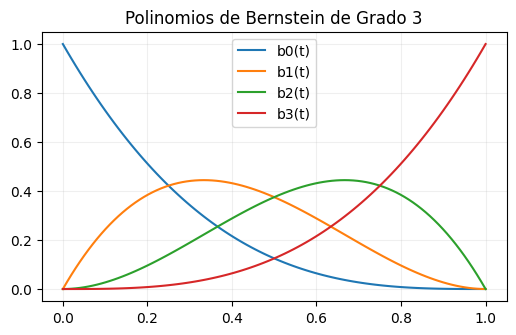

In [8]:
t = np.linspace(0, 1, 100)
b0 = (1-t)**3
b1 = 3*(1-t)**2 * t
b2 = 3*(1-t) * t**2
b3 = t**3

plt.figure(figsize=(6, 3.5))
plt.plot(t, b0, label='b0(t)')
plt.plot(t, b1, label='b1(t)')
plt.plot(t, b2, label='b2(t)')
plt.plot(t, b3, label='b3(t)')
plt.title("Polinomios de Bernstein de Grado 3")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Ejercicio 15: Competencia de Curvas de Bézier

## Justificación del procedimiento para diseñar la trayectoria

El objetivo del problema es construir una **curva de Bézier cúbica** que conecte la casa de Roberto \(A=(0,0)\) con la casa de Damián \(D=(10,5)\), evitando todos los obstáculos del mapa y procurando que la trayectoria tenga **la menor longitud posible**. Para ello se utilizan cuatro puntos de control:

\[
P_0,\; P_1,\; P_2,\; P_3
\]

donde \(P_0=A\) y \(P_3=D\).

---

### 1. Curva de Bézier cúbica

La curva utilizada está definida por la expresión

\[
B(t) =
(1-t)^3 P_0 +
3(1-t)^2 t P_1 +
3(1-t)t^2 P_2 +
t^3 P_3,
\quad t\in[0,1]
\]

Esta ecuación es una **combinación lineal de los puntos de control**, ponderada por los **polinomios de Bernstein**.  
Desde el punto de vista del álgebra lineal, cada punto de la curva es una combinación convexa de \(P_0,P_1,P_2,P_3\).

---

### 2. Propiedad de la envolvente convexa

Una propiedad fundamental de las curvas de Bézier es que **toda la curva queda contenida dentro del casco convexo de sus puntos de control**.

Esto implica que:

- la trayectoria siempre permanece dentro del polígono formado por  
  \(P_0, P_1, P_2, P_3\)
- si ubicamos este polígono de forma que **rodeé los obstáculos**, entonces la curva también los evitará.

Por esta razón los puntos \(P_1\) y \(P_2\) se eligieron de modo que el polígono de control pase **por la zona superior del mapa**, donde hay más espacio libre.

---

### 3. Tangentes en los extremos

Otra propiedad importante de las curvas de Bézier cúbicas es que la **dirección de la tangente en los extremos** depende de los vectores

\[
B'(0) = 3(P_1 - P_0)
\]

\[
B'(1) = 3(P_3 - P_2)
\]

Esto significa que:

- el vector \(P_1 - P_0\) determina **la dirección inicial del movimiento**
- el vector \(P_3 - P_2\) determina **cómo llega la curva al punto final**

En el diseño de la trayectoria:

- \(P_1\) se posiciona **por encima de \(P_0\)** para que la curva suba rápidamente y evite el pozo cercano.
- \(P_2\) se ubica **antes del destino pero también elevado**, lo que genera una llegada suave al punto \(D\) sin pasar por la casa abandonada ni por los arbustos.

---

### 4. Uso de combinaciones lineales para posicionar los puntos

Los puntos \(P_1\) y \(P_2\) se ajustaron utilizando combinaciones lineales y una búsqueda numérica para encontrar posiciones que cumplan simultáneamente:

1. evitar la intersección con los obstáculos,
2. mantener la trayectoria lo más recta posible,
3. minimizar la longitud total de la curva.

En términos geométricos, el algoritmo genera distintas configuraciones de \(P_1\) y \(P_2\) dentro de la región libre y calcula la longitud de la curva resultante.  
Entre todas las trayectorias válidas se selecciona la que posee **la menor longitud**.

---

### 5. Conclusión

El método utilizado combina propiedades geométricas de las curvas de Bézier con conceptos de álgebra lineal:

- uso de **combinaciones convexas** para definir la curva,
- aprovechamiento de la **envolvente convexa** para garantizar que la trayectoria no atraviese obstáculos,
- control de la **dirección de las tangentes** mediante los vectores \(P_1-P_0\) y \(P_3-P_2\).

De esta manera se obtiene una trayectoria suave, continua y válida, que conecta los puntos \(A\) y \(D\) evitando los obstáculos y manteniendo una longitud cercana a la mínima posible.

P1: [3.86446919 6.01366949]
P2: [4.08568731 4.22858715]
Longitud: 12.071907537497035


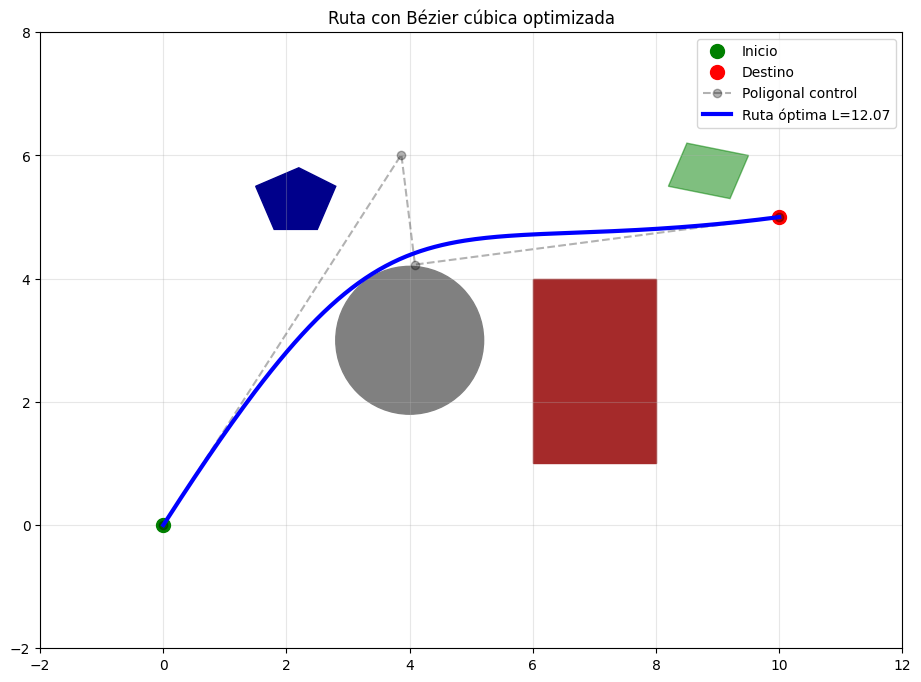

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

# -----------------------------
# BEZIER CUBICA
# -----------------------------
def bezier3(P0,P1,P2,P3,n=200):

    t=np.linspace(0,1,n)

    B=(np.outer((1-t)**3,P0)
      +np.outer(3*(1-t)**2*t,P1)
      +np.outer(3*(1-t)*t**2,P2)
      +np.outer(t**3,P3))

    return B


def longitud(curva):

    d=np.diff(curva,axis=0)
    return np.sum(np.sqrt((d**2).sum(axis=1)))


# -----------------------------
# COLISIONES
# -----------------------------
def punto_en_poligono(p,poly):

    x,y=p
    inside=False

    for i in range(len(poly)):

        x1,y1=poly[i]
        x2,y2=poly[(i+1)%len(poly)]

        if ((y1>y)!=(y2>y)) and (x<(x2-x1)*(y-y1)/(y2-y1)+x1):
            inside=not inside

    return inside


def colision(p,obstaculos):

    for obs in obstaculos:

        if obs["tipo"]=="circulo":

            if np.linalg.norm(p-obs["centro"])<=obs["radio"]:
                return True

        elif obs["tipo"]=="rectangulo":

            if obs["xmin"]<=p[0]<=obs["xmax"] and obs["ymin"]<=p[1]<=obs["ymax"]:
                return True

        elif obs["tipo"]=="poligono":

            if punto_en_poligono(p,obs["verts"]):
                return True

    return False


# -----------------------------
# OPTIMIZACION ALEATORIA
# -----------------------------
def optimizar_ruta(P0,P3,obstaculos,iteraciones=6000):

    mejor_L=np.inf
    mejor=None

    for _ in range(iteraciones):

        P1=np.array([np.random.uniform(1,6),np.random.uniform(4,8)])
        P2=np.array([np.random.uniform(4,10),np.random.uniform(4,8)])

        curva=bezier3(P0,P1,P2,P3)

        choque=False

        for p in curva:
            if colision(p,obstaculos):
                choque=True
                break

        if choque:
            continue

        L=longitud(curva)

        if L<mejor_L:
            mejor_L=L
            mejor=(P1,P2)

    return mejor,mejor_L


# -----------------------------
# OBSTACULOS
# -----------------------------
obstaculos=[

{"tipo":"circulo","centro":np.array([4,3]),"radio":1.2},

{"tipo":"rectangulo","xmin":6,"xmax":8,"ymin":1,"ymax":4},

{"tipo":"poligono","verts":np.array([(1.5,5.5),(2.2,5.8),(2.8,5.5),(2.5,4.8),(1.8,4.8)])},

{"tipo":"poligono","verts":np.array([(8.5,6.2),(9.5,6.0),(9.2,5.3),(8.2,5.5)])}

]


# -----------------------------
# EJECUCION
# -----------------------------
P0=np.array([0,0])
P3=np.array([10,5])

(P1,P2),L=optimizar_ruta(P0,P3,obstaculos,8000)

ruta=bezier3(P0,P1,P2,P3)

print("P1:",P1)
print("P2:",P2)
print("Longitud:",L)


# -----------------------------
# GRAFICO
# -----------------------------
fig,ax=plt.subplots(figsize=(12,8))

ax.set_xlim(-2,12)
ax.set_ylim(-2,8)
ax.set_aspect("equal")
ax.grid(True,alpha=0.3)

ax.plot(P0[0],P0[1],'go',markersize=10,label="Inicio")
ax.plot(P3[0],P3[1],'ro',markersize=10,label="Destino")

# Obstaculos
ax.add_patch(Circle((4,3),1.2,color="gray"))

ax.add_patch(Rectangle((6,1),2,3,color="brown"))

pozo=np.array([(1.5,5.5),(2.2,5.8),(2.8,5.5),(2.5,4.8),(1.8,4.8)])
arb=np.array([(8.5,6.2),(9.5,6.0),(9.2,5.3),(8.2,5.5)])

ax.add_patch(Polygon(pozo,color="darkblue"))
ax.add_patch(Polygon(arb,color="green",alpha=0.5))

# Poligonal
ctrl=np.array([P0,P1,P2,P3])
ax.plot(ctrl[:,0],ctrl[:,1],'ko--',alpha=0.3,label="Poligonal control")

# Curva
ax.plot(ruta[:,0],ruta[:,1],'b',linewidth=3,label=f"Ruta óptima L={L:.2f}")

ax.legend()
plt.title("Ruta con Bézier cúbica optimizada")
plt.show()

## 14. Cambio entre base monomial y base de Bernstein (Ejercicio 10)

Los polinomios de Bernstein de grado 3 son:

- $b_0(t) = (1-t)^3$
- $b_1(t) = 3(1-t)^2 t$
- $b_2(t) = 3(1-t)t^2$
- $b_3(t) = t^3$

Escribiéndolos en la base monomial $\{1,t,t^2,t^3\}$ obtenemos los vectores de coordenadas:

$$
(1-t)^3 = 1 -3t +3t^2 -t^3
$$

$$
3(1-t)^2 t = 3t -6t^2 +3t^3
$$

$$
3(1-t)t^2 = 3t^2 -3t^3
$$

$$
t^3 = t^3
$$

Por lo tanto la matriz que transforma coordenadas desde la base de Bernstein hacia la base monomial es:

$$
A =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
-3 & 3 & 0 & 0 \\
3 & -6 & 3 & 0 \\
-1 & 3 & -3 & 1
\end{pmatrix}
$$


In [10]:
import numpy as np

A = np.array([
[1,0,0,0],
[-3,3,0,0],
[3,-6,3,0],
[-1,3,-3,1]
])

detA = np.linalg.det(A)

print("Matriz de cambio de base A:")
print(A)
print("\nDeterminante:", detA)
print("Invertible:", detA != 0)


Matriz de cambio de base A:
[[ 1  0  0  0]
 [-3  3  0  0]
 [ 3 -6  3  0]
 [-1  3 -3  1]]

Determinante: 9.000000000000002
Invertible: True


## 15. Implementación computacional (Ejercicio 11)

Implementamos una curva de Bézier cuadrática

$$
B(t) = (1-t)^2 P_0 + 2(1-t)t P_1 + t^2 P_2
$$


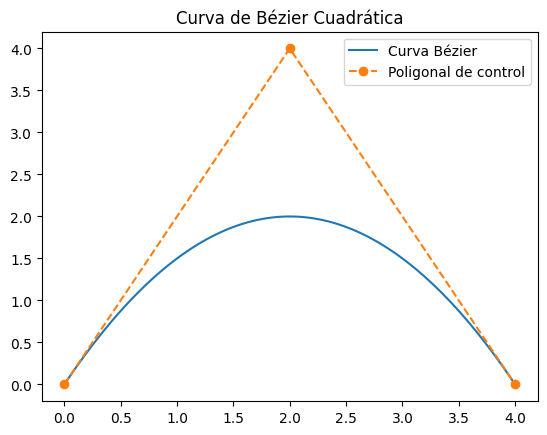

0.0 [0. 0.] [0. 0.]
0.1111111111111111 [0.44444444 0.79012346] [0.44444444 0.79012346]
0.2222222222222222 [0.88888889 1.38271605] [0.88888889 1.38271605]
0.3333333333333333 [1.33333333 1.77777778] [1.33333333 1.77777778]
0.4444444444444444 [1.77777778 1.97530864] [1.77777778 1.97530864]
0.5555555555555556 [2.22222222 1.97530864] [2.22222222 1.97530864]
0.6666666666666666 [2.66666667 1.77777778] [2.66666667 1.77777778]
0.7777777777777777 [3.11111111 1.38271605] [3.11111111 1.38271605]
0.8888888888888888 [3.55555556 0.79012346] [3.55555556 0.79012346]
1.0 [4. 0.] [4. 0.]


In [11]:
import numpy as np
import matplotlib.pyplot as plt

P0 = np.array([0,0])
P1 = np.array([2,4])
P2 = np.array([4,0])

def bezier_quadratica(P0,P1,P2,t):
    return (1-t)**2 * P0 + 2*(1-t)*t * P1 + t**2 * P2

t_vals = np.linspace(0,1,100)
curve = np.array([bezier_quadratica(P0,P1,P2,t) for t in t_vals])

control = np.array([P0,P1,P2])

plt.figure()
plt.plot(curve[:,0], curve[:,1], label="Curva Bézier")
plt.plot(control[:,0], control[:,1], 'o--', label="Poligonal de control")
plt.legend()
plt.title("Curva de Bézier Cuadrática")
plt.show()

# comparación con interpolación iterada

def de_casteljau(P0,P1,P2,t):
    Q0 = (1-t)*P0 + t*P1
    Q1 = (1-t)*P1 + t*P2
    B = (1-t)*Q0 + t*Q1
    return B

for t in np.linspace(0,1,10):
    print(t, bezier_quadratica(P0,P1,P2,t), de_casteljau(P0,P1,P2,t))


## 16. Curvas de orden superior (Ejercicio 12)

Definimos

- $g_1(t)$ con puntos $P_0,P_1,P_2$
- $g_2(t)$ con puntos $P_1,P_2,P_3$

y

$$
h(t) = (1-t)g_1(t) + t g_2(t)
$$

Esto produce una **curva de Bézier cúbica** con puntos de control $P_0,P_1,P_2,P_3$.


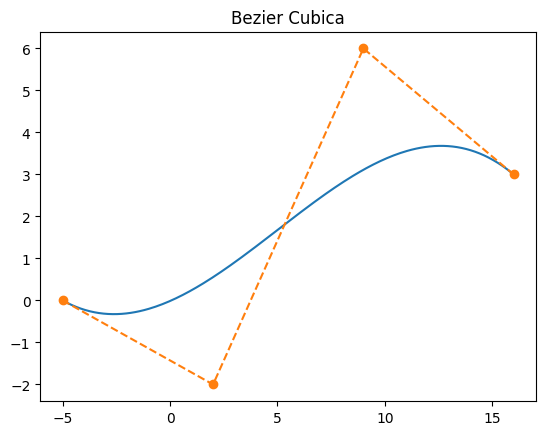

h'(0) = [21 -6]
h'(1) = [21 -9]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

P0 = np.array([-5,0])
P1 = np.array([2,-2])
P2 = np.array([9,6])
P3 = np.array([16,3])

def h(t,points):
    P0,P1,P2,P3 = points
    return ((1-t)**3)*P0 + 3*(1-t)**2*t*P1 + 3*(1-t)*t**2*P2 + t**3*P3

points=[P0,P1,P2,P3]

t=np.linspace(0,1,200)
curve=np.array([h(tt,points) for tt in t])

control=np.array(points)

plt.figure()
plt.plot(curve[:,0],curve[:,1])
plt.plot(control[:,0],control[:,1],'o--')
plt.title("Bezier Cubica")
plt.show()

# derivadas
def h_prime(t):
    return 3*(1-t)**2*(P1-P0)+6*(1-t)*t*(P2-P1)+3*t**2*(P3-P2)

def h_second(t):
    return 6*(1-t)*(P2-2*P1+P0)+6*t*(P3-2*P2+P1)

print("h'(0) =",h_prime(0))
print("h'(1) =",h_prime(1))


## 17. Figuras cerradas (Ejercicio 13)

Generamos dos curvas de Bézier cúbicas aleatorias y verificamos que una transformación lineal
aplicada a la curva sigue produciendo otra curva de Bézier.


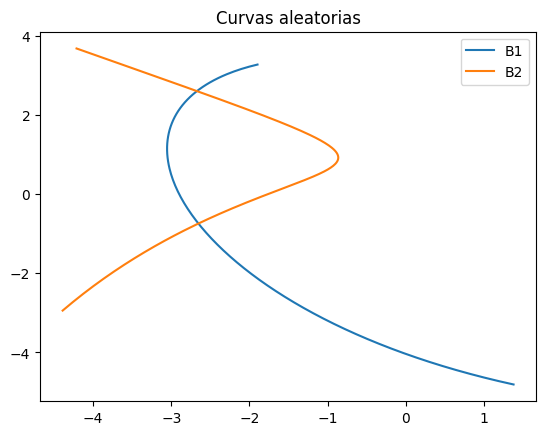

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def random_points():
    return np.random.uniform(-5,5,(4,2))

def bezier(points,t):
    P0,P1,P2,P3 = points
    return ((1-t)**3)*P0 + 3*(1-t)**2*t*P1 + 3*(1-t)*t**2*P2 + t**3*P3

P=random_points()
Q=random_points()

t=np.linspace(0,1,200)

B1=np.array([bezier(P,tt) for tt in t])
B2=np.array([bezier(Q,tt) for tt in t])

plt.figure()
plt.plot(B1[:,0],B1[:,1],label="B1")
plt.plot(B2[:,0],B2[:,1],label="B2")
plt.legend()
plt.title("Curvas aleatorias")
plt.show()


## 18. Continuidad de curvas compuestas (Ejercicio 14)

Para dos curvas cúbicas consecutivas:

- $B_1(t)$ con puntos $P_0,P_1,P_2,P_3$
- $B_2(t)$ con puntos $P_3,P_4,P_5,P_6$

### Condición de continuidad $C^1$

Debe cumplirse

$$
B'_1(1) = B'_2(0)
$$

Para curvas de Bézier cúbicas

$$
B'_1(1) = 3(P_3-P_2)
$$

$$
B'_2(0) = 3(P_4-P_3)
$$

Por lo tanto la condición es

$$
P_3 - P_2 = P_4 - P_3
$$

o equivalentemente

$$
P_4 = 2P_3 - P_2
$$

Esto significa que los puntos $P_2,P_3,P_4$ deben estar **alineados**.

### Caso donde las derivadas son cero

Si

$$
B'_1(1) = B'_2(0) = 0
$$

la curva tiene un **punto estacionario** en $P_3$.

### Continuidad $C^2$

Imponiendo

$$
B''_1(1) = B''_2(0)
$$

se obtiene que

$$
P_5 = P_1 - 4P_2 + 4P_3
$$

por lo que $P_5$ queda completamente determinado por $P_1,P_2,P_3$.
